In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('C:/Users/CHANDRIMA/Desktop/superstore-analysis/data/superstore_cleaned.csv')
sns.set_theme(style="whitegrid")

print("Data loaded successfully!")
print(f"Shape: {df.shape}")

Data loaded successfully!
Shape: (9994, 25)


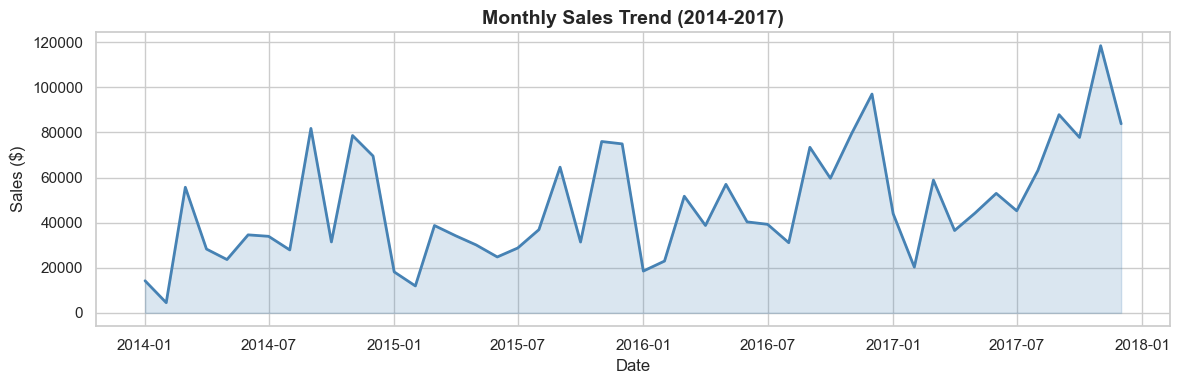

Chart 1 saved!


In [2]:
# Prepare the data
monthly = df.groupby(['Order Year', 'Order Month'])['Sales'].sum().reset_index()
monthly['Date'] = pd.to_datetime(
    monthly['Order Year'].astype(str) + '-' + monthly['Order Month'].astype(str) + '-01'
)
monthly = monthly.sort_values('Date')

# Create the chart
plt.figure(figsize=(12, 4))
plt.plot(monthly['Date'], monthly['Sales'], color='steelblue', linewidth=2)
plt.fill_between(monthly['Date'], monthly['Sales'], alpha=0.2, color='steelblue')
plt.title('Monthly Sales Trend (2014-2017)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.tight_layout()
plt.savefig('C:/Users/CHANDRIMA/Desktop/superstore-analysis/data/sales_trend.png', dpi=150)
plt.show()
print("Chart 1 saved!")

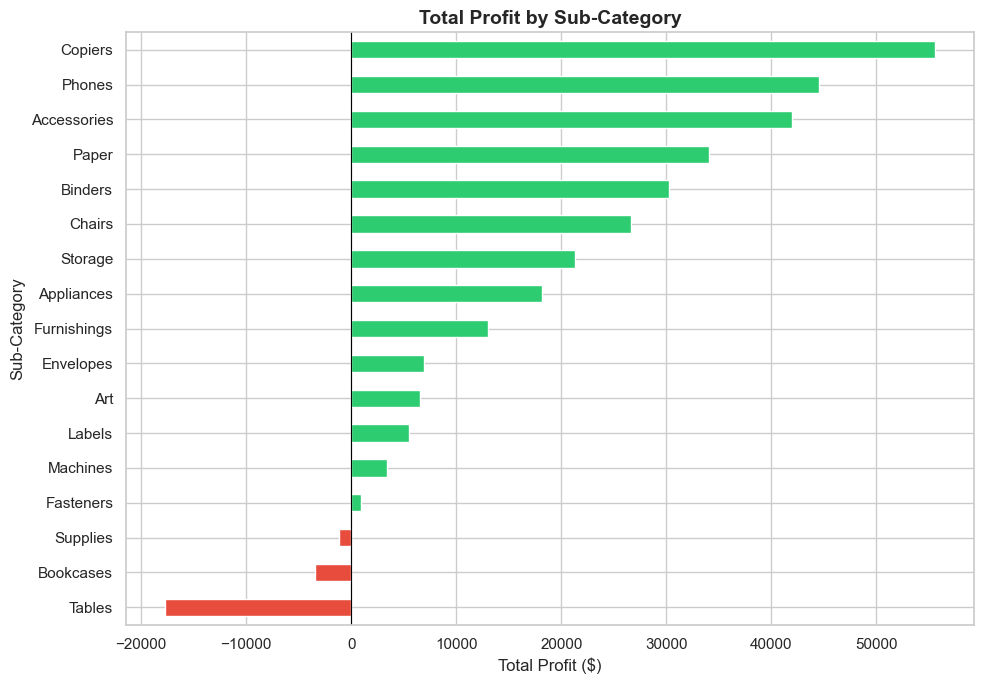

Chart 2 saved!


In [3]:
# Prepare the data
cat_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()

# Create colors - red for loss, green for profit
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in cat_profit]

# Create the chart
plt.figure(figsize=(10, 7))
cat_profit.plot(kind='barh', color=colors)
plt.title('Total Profit by Sub-Category', fontsize=14, fontweight='bold')
plt.xlabel('Total Profit ($)')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('C:/Users/CHANDRIMA/Desktop/superstore-analysis/data/profit_by_category.png', dpi=150)
plt.show()
print("Chart 2 saved!")

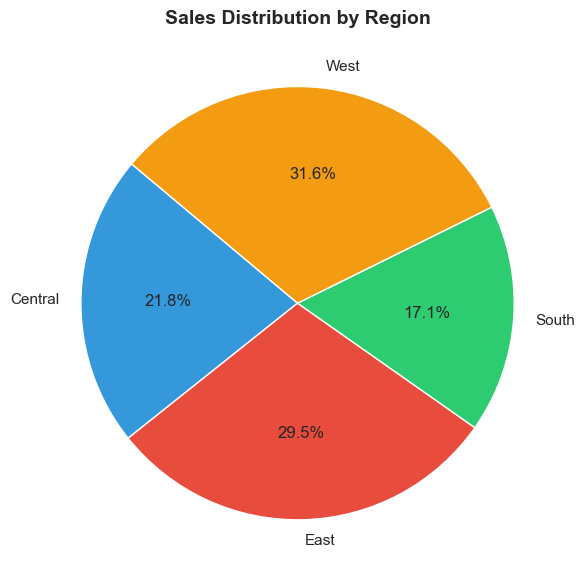

Chart 3 saved!


In [4]:
# Prepare the data
region_sales = df.groupby('Region')['Sales'].sum()

# Create the chart
plt.figure(figsize=(8, 6))
plt.pie(
    region_sales,
    labels=region_sales.index,
    autopct='%1.1f%%',
    colors=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'],
    startangle=140
)
plt.title('Sales Distribution by Region', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('C:/Users/CHANDRIMA/Desktop/superstore-analysis/data/sales_by_region.png', dpi=150)
plt.show()
print("Chart 3 saved!")

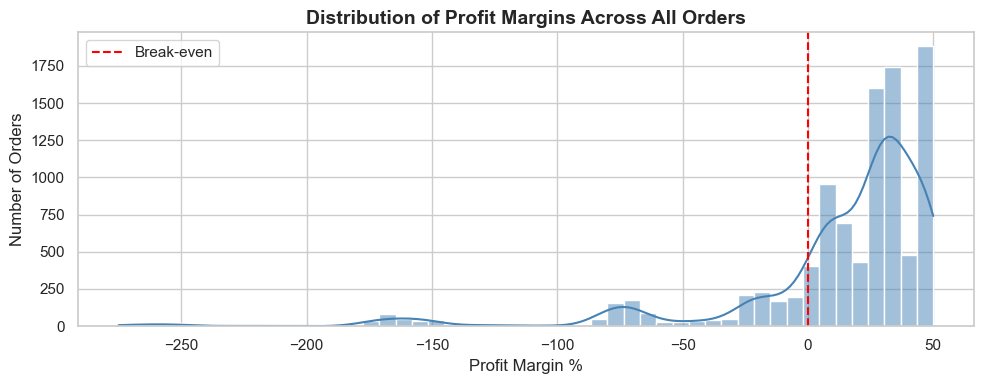

Chart 4 saved!


In [5]:
# Create the chart
plt.figure(figsize=(10, 4))
sns.histplot(df['Profit Margin %'], bins=50, kde=True, color='steelblue')
plt.title('Distribution of Profit Margins Across All Orders', fontsize=14, fontweight='bold')
plt.xlabel('Profit Margin %')
plt.ylabel('Number of Orders')
plt.axvline(x=0, color='red', linewidth=1.5, linestyle='--', label='Break-even')
plt.legend()
plt.tight_layout()
plt.savefig('C:/Users/CHANDRIMA/Desktop/superstore-analysis/data/margin_distribution.png', dpi=150)
plt.show()
print("Chart 4 saved!")

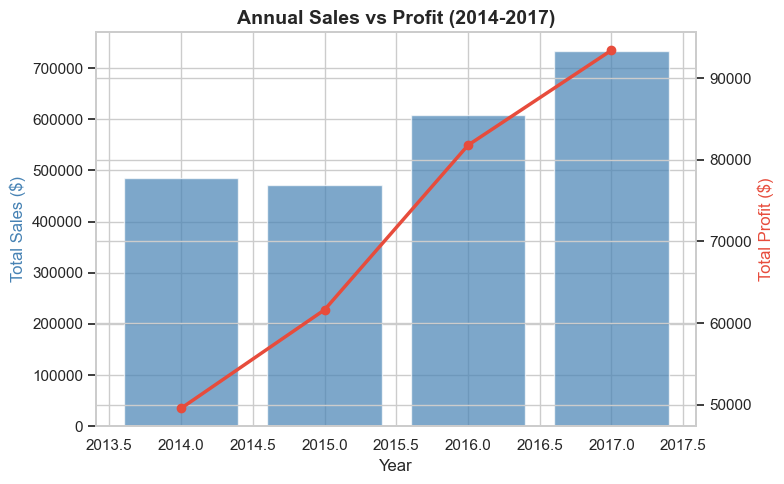

Chart 5 saved!


In [6]:
# Prepare the data
yearly = df.groupby('Order Year')[['Sales', 'Profit']].sum().reset_index()

# Create the chart
fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.bar(yearly['Order Year'], yearly['Sales'], color='steelblue', alpha=0.7, label='Sales')
ax1.set_xlabel('Year')
ax1.set_ylabel('Total Sales ($)', color='steelblue')

ax2 = ax1.twinx()
ax2.plot(yearly['Order Year'], yearly['Profit'], color='#e74c3c', linewidth=2.5, marker='o', label='Profit')
ax2.set_ylabel('Total Profit ($)', color='#e74c3c')

plt.title('Annual Sales vs Profit (2014-2017)', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.savefig('C:/Users/CHANDRIMA/Desktop/superstore-analysis/data/yearly_sales_profit.png', dpi=150)
plt.show()
print("Chart 5 saved!")